# PHẦN 2. KHÁM PHÁ VÀ CHUYỂN ĐỔI DỮ LIỆU

## 2.1. Tính Monthly Return

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("../data/msft_macro_2021_2026.csv")

# Chuyển Date sang kiểu datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sắp xếp dữ liệu theo thời gian
df = df.sort_values("Date").reset_index(drop=True)

# Kiểm tra dữ liệu
print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (68, 4)


,Date,MSFT_Price,Interest_Rate,Inflation_Rate
0,2021-01-31,221.1717,0.09,1.3738
1,2021-02-28,222.0825,0.08,1.6698
2,2021-03-31,225.3223,0.07,2.6678
3,2021-04-30,241.0051,0.07,4.1331
4,2021-05-31,239.1668,0.06,4.9183


In [3]:
# Tính Monthly Return (%)
df["Monthly_Return"] = df["MSFT_Price"].pct_change() * 100

# Hiển thị kết quả
display(
    df[
        ["Date", "MSFT_Price", "Monthly_Return"]
    ].head(10)
)

,Date,MSFT_Price,Monthly_Return
0,2021-01-31,221.1717,NaN
1,2021-02-28,222.0825,0.411807
2,2021-03-31,225.3223,1.458827
3,2021-04-30,241.0051,6.960163
4,2021-05-31,239.1668,-0.762764
5,2021-06-30,259.4933,8.498880
6,2021-07-31,272.9135,5.171694
7,2021-08-31,289.7225,6.159094
8,2021-09-30,270.5663,-6.611913
9,2021-10-31,318.2648,17.629136


In [4]:
# Kiểm tra giá trị thiếu
print("Missing values của Monthly Return:")
print(df["Monthly_Return"].isna().sum())

Missing values của Monthly Return:
1


In [5]:
# Loại bỏ dòng đầu tiên không thể tính Monthly Return
df = df.dropna(subset=["Monthly_Return"]).reset_index(drop=True)

print("Số dòng sau khi loại bỏ giá trị thiếu:", len(df))

Số dòng sau khi loại bỏ giá trị thiếu: 67


## 2.2. Thống kê mô tả

In [6]:
variables = [
    "Monthly_Return",
    "Interest_Rate",
    "Inflation_Rate"
]

desc = df[variables].describe().T

display(desc)

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,67.0,1.527267,7.641065,-17.150852,-4.483244,0.901797,6.889627,24.583133
Interest_Rate,67.0,3.324030,1.982045,0.060000,1.445000,4.100000,4.945000,5.330000
Inflation_Rate,67.0,4.394751,2.064729,1.669800,2.836150,3.353000,5.654500,8.979400


## 2.3. Phân tích tương quan

In [7]:
corr_matrix = df[
    ["Monthly_Return", "Interest_Rate", "Inflation_Rate"]
].corr()

print("=== MA TRẬN TƯƠNG QUAN ===")
display(corr_matrix)

=== MA TRẬN TƯƠNG QUAN ===


,Monthly_Return,Interest_Rate,Inflation_Rate
Monthly_Return,1.000000,0.068885,-0.105990
Interest_Rate,0.068885,1.000000,-0.591219
Inflation_Rate,-0.105990,-0.591219,1.000000


## 2.4. Vẽ biểu đồ xu hướng và Scatter Plot

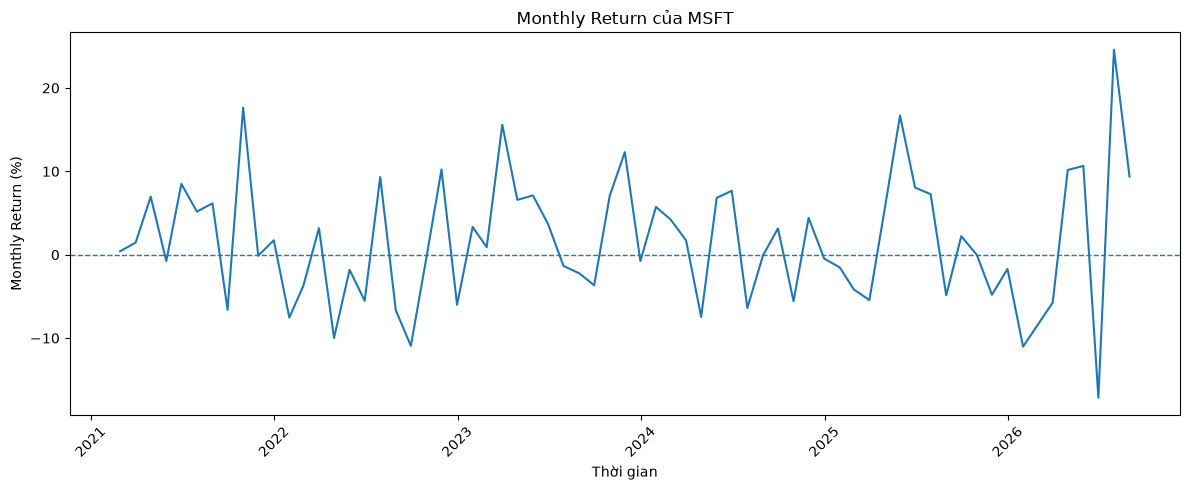

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Monthly_Return"],
    linewidth=1.5
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Monthly Return của MSFT")
plt.xlabel("Thời gian")
plt.ylabel("Monthly Return (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

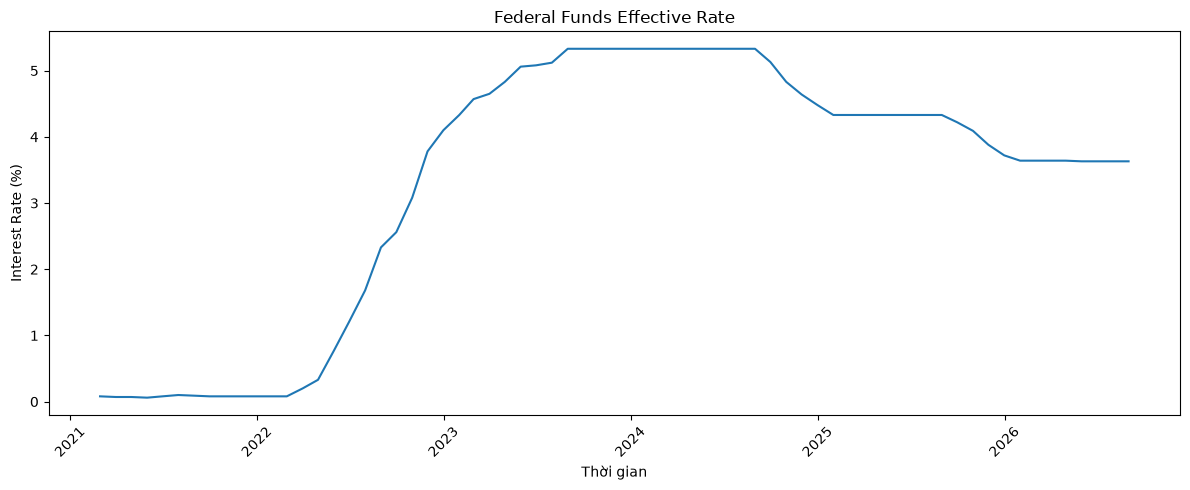

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Interest_Rate"],
    linewidth=1.5
)

plt.title("Federal Funds Effective Rate")
plt.xlabel("Thời gian")
plt.ylabel("Interest Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

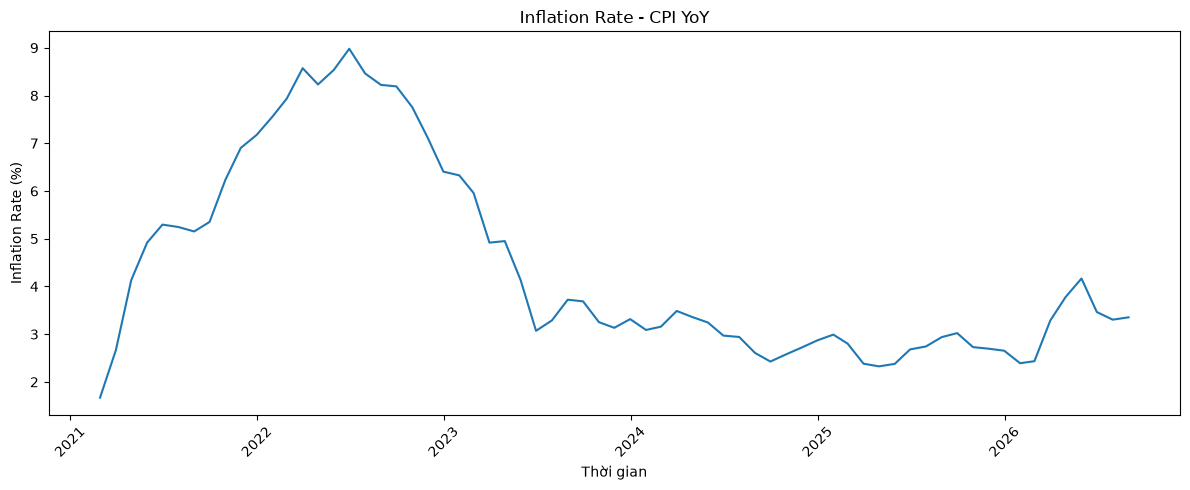

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Inflation_Rate"],
    linewidth=1.5
)

plt.title("Inflation Rate - CPI YoY")
plt.xlabel("Thời gian")
plt.ylabel("Inflation Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Scatter Plot giữa Monthly Return và Interest Rate

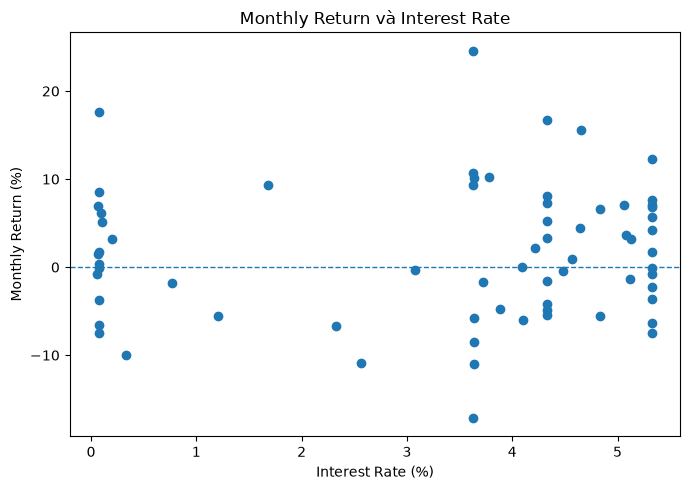

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Interest_Rate"],
    df["Monthly_Return"]
)

plt.title("Monthly Return và Interest Rate")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Monthly Return (%)")

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.tight_layout()
plt.show()

### Scatter Plot giữa Monthly Return và Inflation Rate

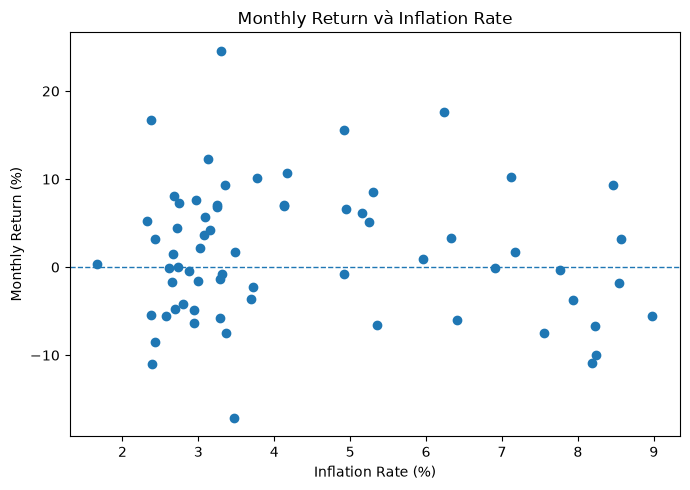

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Inflation_Rate"],
    df["Monthly_Return"]
)

plt.title("Monthly Return và Inflation Rate")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Monthly Return (%)")

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.tight_layout()
plt.show()

## 2.5. Phát hiện và phân tích Outlier

In [13]:
variables = [
    "Monthly_Return",
    "Interest_Rate",
    "Inflation_Rate"
]

for col in variables:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n===== {col} =====")
    print(f"Q1              : {Q1:.4f}")
    print(f"Q3              : {Q3:.4f}")
    print(f"IQR             : {IQR:.4f}")
    print(f"Lower Bound     : {lower_bound:.4f}")
    print(f"Upper Bound     : {upper_bound:.4f}")
    print(f"Số lượng Outlier: {len(outliers)}")

    if len(outliers) > 0:
        display(
            outliers[
                ["Date", col]
            ]
        )


===== Monthly_Return =====
Q1              : -4.4832
Q3              : 6.8896
IQR             : 11.3729
Lower Bound     : -21.5426
Upper Bound     : 23.9489
Số lượng Outlier: 1


,Date,Monthly_Return
65,2026-07-31,24.583133



===== Interest_Rate =====
Q1              : 1.4450
Q3              : 4.9450
IQR             : 3.5000
Lower Bound     : -3.8050
Upper Bound     : 10.1950
Số lượng Outlier: 0

===== Inflation_Rate =====
Q1              : 2.8361
Q3              : 5.6545
IQR             : 2.8184
Lower Bound     : -1.3914
Upper Bound     : 9.8820
Số lượng Outlier: 0
